In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation

dimension of X: (100, 2)
dimension of y: (100, 1)


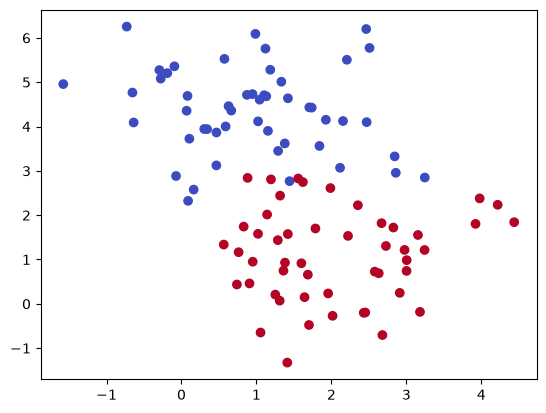

In [16]:
X,y = make_blobs(n_samples=100, n_features=2, random_state=0, centers=2)
y = y.reshape(y.shape[0], 1)

print('dimension of X:', X.shape)
print('dimension of y:', y.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

In [17]:
def initialize_parameters(input_size, hidden_size=8, seed=42):
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0, np.sqrt(2 / input_size), (input_size, hidden_size)),
        "b1": np.zeros((1, hidden_size)),
        "W2": rng.normal(0, np.sqrt(1 / hidden_size), (hidden_size, 1)),
        "b2": np.zeros((1, 1)),
    }

In [18]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def forward_propagation(X, parameters):
    Z1 = X @ parameters["W1"] + parameters["b1"]
    A1 = np.maximum(0, Z1)
    Z2 = A1 @ parameters["W2"] + parameters["b2"]
    A2 = sigmoid(Z2)
    cache = {"Z1": Z1, "A1": A1, "A2": A2}
    return A2, cache


def model(X, parameters):
    probabilities, _ = forward_propagation(X, parameters)
    return probabilities

In [19]:
def log_loss(y, A):
    epsilon = 1e-12
    A = np.clip(A, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(A) + (1 - y) * np.log(1 - A))

In [20]:
def gradient_descent(A2, X, y, parameters, cache):
    m = X.shape[0]
    dZ2 = A2 - y
    dW2 = cache["A1"].T @ dZ2 / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dA1 = dZ2 @ parameters["W2"].T
    dZ1 = dA1 * (cache["Z1"] > 0)
    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

In [21]:
def update_parameters(parameters, gradients, learning_rate):
    return {
        key: parameters[key] - learning_rate * gradients[key]
        for key in parameters
    }

In [22]:
def predict(X, parameters):
    return (model(X, parameters) >= 0.5).astype(int)

In [23]:
def artificial_neural_network(X, y, learning_rate=0.05, num_iterations=2000, hidden_size=8):
    parameters = initialize_parameters(X.shape[1], hidden_size)
    loss_history = []

    for _ in range(num_iterations):
        A2, cache = forward_propagation(X, parameters)
        loss_history.append(log_loss(y, A2))
        gradients = gradient_descent(A2, X, y, parameters, cache)
        parameters = update_parameters(parameters, gradients, learning_rate)

    y_pred = predict(X, parameters)
    print('Précision :', accuracy_score(y.ravel(), y_pred.ravel()))
    plt.plot(loss_history)
    plt.xlabel('Itération')
    plt.ylabel('Coût')
    plt.show()

    return parameters

Précision : 0.94


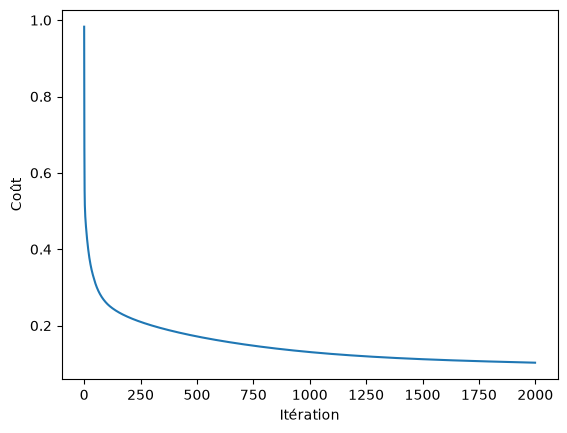

In [24]:
parameters = artificial_neural_network(X, y)

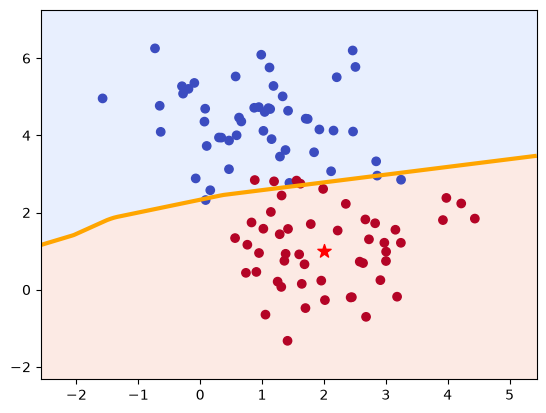

Probability of class 1: [[0.9967241]]
Predicted class: [[1]]


In [25]:
new_plant = np.array([[2, 1]])
x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 150)
x1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 150)
grid_x, grid_y = np.meshgrid(x0, x1)
grid = np.column_stack((grid_x.ravel(), grid_y.ravel()))
probabilities = model(grid, parameters).reshape(grid_x.shape)

plt.contourf(grid_x, grid_y, probabilities, levels=[0, 0.5, 1], alpha=0.2, cmap='coolwarm')
plt.contour(grid_x, grid_y, probabilities, levels=[0.5], colors='orange', linewidths=3)
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='coolwarm')
plt.scatter(new_plant[0, 0], new_plant[0, 1], c='r', s=100, marker='*')
plt.show()

print('Probability of class 1:', model(new_plant, parameters))
print('Predicted class:', predict(new_plant, parameters))

In [26]:

fig = go.Figure(data=[go.Scatter3d(
    x=X[:, 0].flatten(),
    y=X[:, 1].flatten(),
    z=y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity=0.8,
        reversescale=True
    )
)])

fig.update_layout(
    template='plotly_dark',
    margin=dict(l=0, r=0, t=0)
)

fig.layout.scene.camera.projection.type = 'orthographic'

fig.show()

In [27]:

x0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)

x0, x1 = np.meshgrid(x0, x1)

grid = np.column_stack((x0.ravel(), x1.ravel()))
A = model(grid, parameters).reshape(x0.shape)

# Create figure with probability surface
fig = go.Figure(data=[
    go.Surface(
        z=A,
        x=x0,
        y=x1,
        colorscale='YlGn',
        opacity=0.7,
        reversescale=True
    )
])

# Add data points
fig.add_scatter3d(
    x=X[:, 0].flatten(),
    y=X[:, 1].flatten(),
    z=y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity=0.9,
        reversescale=True
    )
)

# Layout
fig.update_layout(
    template='plotly_dark',
    margin=dict(l=0, r=0, t=0)
)

fig.layout.scene.camera.projection.type = 'orthographic'

fig.show()